# Creating the ______-iest image
In our project, we take inspiration from the Glitch Tokens Computerphile video from earlier in the semester. Ideally we would like to find the image that perfectly matches embeddings with a given prompt. We were not able to run the model "backwards" as suggested in that video to produce an image from the given embedding; however, we are able to produce images with 0.97+ cosine similarity to the prompt embedding.

(this project should run in co-lab easily)

### Loading our CLIP model

In [1]:
from transformers import CLIPProcessor, CLIPModel

# Load the CLIP preprocessor
processor = CLIPProcessor.from_pretrained('openai/clip-vit-base-patch32')

# Load the pre-trained CLIP model
model = CLIPModel.from_pretrained('openai/clip-vit-base-patch32')

print("CLIP preprocessor and model loaded successfully.")

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/316 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/592 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/605M [00:00<?, ?B/s]

CLIP preprocessor and model loaded successfully.


In [2]:
'''
from transformers import CLIPProcessor, CLIPModel

# Load the CLIP preprocessor
processor = CLIPProcessor.from_pretrained('openai/clip-vit-base-patch32')

# Load the pre-trained CLIP model
model = CLIPModel.from_pretrained('openai/clip-vit-base-patch32')

print("CLIP preprocessor and model loaded successfully.")
'''

model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]

CLIP preprocessor and model loaded successfully.


### Setting up the prompt
Here we get our prompt embedding to guide the image generation

In [9]:
import torch

# 1. Define a string variable for the text prompt
text_prompt = "goldfish"

# 2. Use the processor to tokenize the text_prompt, explicitly specifying it as text
inputs = processor(text=text_prompt, return_tensors="pt")

# Determine the device (GPU if available, otherwise CPU)
device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device)

# Move inputs to the device
inputs = {k: v.to(device) for k, v in inputs.items()}

# 3. Pass the tokenized input to the model's get_text_features method to obtain the text embedding
text_embedding = model.get_text_features(**inputs)

# 4. Ensure the text_embedding is moved to the appropriate device (already handled above)

print(f"Text prompt: '{text_prompt}'")
print(f"Text embedding shape: {text_embedding.shape}")
print(f"Text embedding device: {text_embedding.device}")

Text prompt: 'goldfish'
Text embedding shape: torch.Size([1, 512])
Text embedding device: cpu


### Set up image
This cell defines our image dimensions and generates random noise to start from.


In [10]:
import torch

# 1. Define desired image dimensions (224x224 RGB)
image_height = 224
image_width = 224
image_channels = 3 # RGB

# Determine the device (GPU if available, otherwise CPU) - already defined as 'device'

# 2. Initialize a PyTorch tensor with random noise
# Shape: (batch_size, channels, height, width). For a single image, batch_size is 1.
starting_image = torch.randn(1, image_channels, image_height, image_width, device=device, dtype=torch.float32)

# 3. Set requires_grad=True for the image tensor
starting_image.requires_grad = True

print(f"Initialized starting image tensor with shape: {starting_image.shape}")
print(f"Starting image tensor device: {starting_image.device}")
print(f"Starting image tensor requires_grad: {starting_image.requires_grad}")

Initialized starting image tensor with shape: torch.Size([1, 3, 224, 224])
Starting image tensor device: cpu
Starting image tensor requires_grad: True


### The guts

This is where we train and guide the diffusion process using `1-cosine_similarity(image_embedding, prompt_embedding)` as our loss function.

We also display the image's state every 50 steps.

Starting CLIP Inversion Optimization for 'goldfish'...
Optimization Steps: 500, Learning Rate: 0.05
Step 1/500, Loss: 0.7610, Cosine Similarity: 0.2390, Max Grad: 0.000554


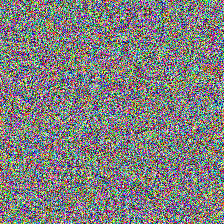

Step 50/500, Loss: 0.2902, Cosine Similarity: 0.7098, Max Grad: 0.002820


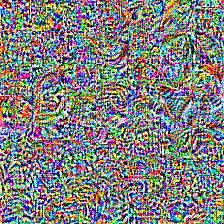

Step 100/500, Loss: 0.1780, Cosine Similarity: 0.8220, Max Grad: 0.005725


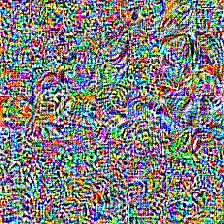

Step 150/500, Loss: 0.0872, Cosine Similarity: 0.9128, Max Grad: 0.005044


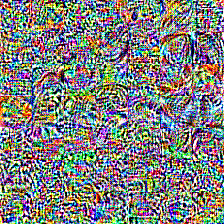

Step 200/500, Loss: 0.0553, Cosine Similarity: 0.9447, Max Grad: 0.004447


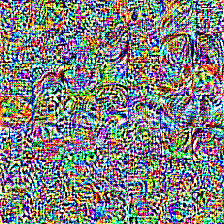

Step 250/500, Loss: 0.0318, Cosine Similarity: 0.9682, Max Grad: 0.003680


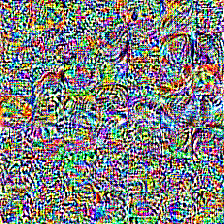

Step 300/500, Loss: 0.0300, Cosine Similarity: 0.9700, Max Grad: 0.003509


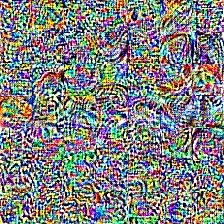

Step 350/500, Loss: 0.0217, Cosine Similarity: 0.9783, Max Grad: 0.004167


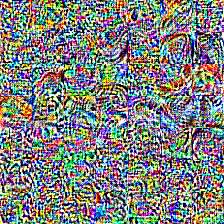

Step 400/500, Loss: 0.0212, Cosine Similarity: 0.9788, Max Grad: 0.004345


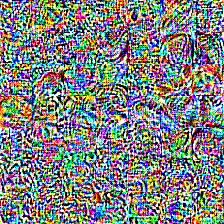

Step 450/500, Loss: 0.0171, Cosine Similarity: 0.9829, Max Grad: 0.004251


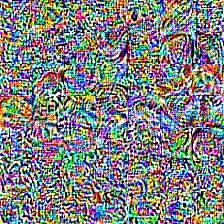

Step 500/500, Loss: 0.0200, Cosine Similarity: 0.9800, Max Grad: 0.004047


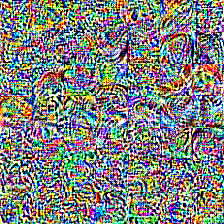

Optimization complete.


In [11]:
import torch.nn.functional as F

# Display interval
display_interval = 50

# 1. Define optimization parameters (keeping existing values)
num_optimization_steps = 500  # Number of iterations
learning_rate = 0.05       # Learning rate for the optimizer

# Define CLIP's expected normalization mean and standard deviation
# These values are specific to the 'openai/clip-vit-base-patch32' model's preprocessing
mean = torch.tensor([0.48145466, 0.4578275, 0.40821073]).to(device).view(1, 3, 1, 1)
std = torch.tensor([0.26862954, 0.26130258, 0.27577711]).to(device).view(1, 3, 1, 1)

# Re-initialize starting_image to ensure values are in [0, 1] range
starting_image = torch.rand(1, image_channels, image_height, image_width, device=device, dtype=torch.float32)
starting_image.requires_grad = True

# 2. Create an Adam optimizer instance, passing the starting_image tensor as parameters
optimizer = torch.optim.Adam([starting_image], lr=learning_rate)

print(f"Starting CLIP Inversion Optimization for '{text_prompt}'...")
print(f"Optimization Steps: {num_optimization_steps}, Learning Rate: {learning_rate}")

# Detach text_embedding_norm once, as it's constant and should not be part of the image's gradient graph
text_embedding_norm_detached = F.normalize(text_embedding, p=2, dim=-1).detach()

# 3. Start an iterative loop
for i in range(num_optimization_steps):
    # 4a. Clear previous gradients
    optimizer.zero_grad()

    # 4b. Resize the starting_image to (224, 224)
    # Interpolate expects (N, C, H, W) and outputs (N, C, H_out, W_out)
    resized_image = F.interpolate(starting_image, size=(224, 224), mode='bicubic', align_corners=False)

    # 4c. Normalize the resized image using the pre-defined mean and std
    normalized_image = (resized_image - mean) / std

    # 4d. Pass the preprocessed image tensor directly to model.get_image_features()
    image_embedding = model.get_image_features(normalized_image)

    # 5. Normalize embeddings for cosine similarity
    image_embedding_norm = F.normalize(image_embedding, p=2, dim=-1)

    # 6. Calculate the cosine similarity using the detached text embedding norm
    cosine_similarity = F.cosine_similarity(image_embedding_norm, text_embedding_norm_detached)

    # 7. Define the loss function (minimize 1 - cosine_similarity to maximize similarity)
    loss = 1 - cosine_similarity

    # 8. Perform backpropagation
    loss.backward()

    # 9. Debugging step: Print max gradient of starting_image
    if starting_image.grad is not None:
        max_grad = starting_image.grad.abs().max().item()
    else:
        max_grad = 0.0 # Should not happen if backward() was called successfully

    # 10. Update the image pixels
    optimizer.step()

    # 11. Clamp the starting_image.data tensor to keep pixel values within a reasonable range (0-1)
    starting_image.data.clamp_(0, 1)

    # 12. Periodically print the current step, loss, cosine similarity, and max gradient
    if (i + 1) % 50 == 0 or i == 0 or i == num_optimization_steps - 1:
        print(f"Step {i+1}/{num_optimization_steps}, Loss: {loss.item():.4f}, Cosine Similarity: {cosine_similarity.item():.4f}, Max Grad: {max_grad:.6f}")

        with torch.no_grad():
          disp_img = starting_image.detach().cpu().squeeze(0).permute(1, 2, 0).clamp(0, 1).numpy()
          disp_pil = Image.fromarray((disp_img * 255).astype(np.uint8))
          display(disp_pil)

print("Optimization complete.")

### Display Results

Lastly we display the resulting image and its the image embedding's cosine similarity to the original prompt's embedding.


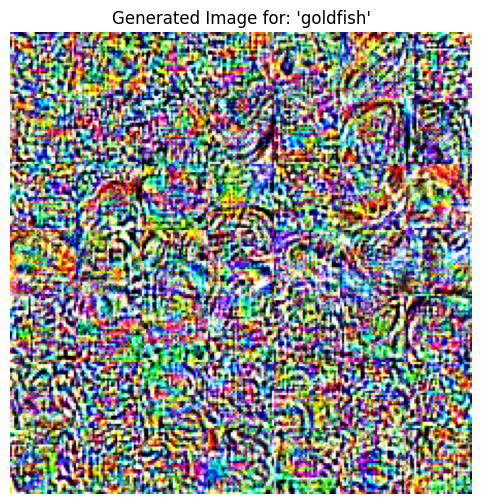

Generated image displayed successfully.


In [12]:
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np

# 1. Convert the starting_image tensor to a NumPy array
# Ensure it's on CPU and detached from the computation graph, then convert to NumPy
# The tensor is (1, C, H, W) and needs to be (H, W, C) for PIL/matplotlib
inverted_image_tensor = starting_image.detach().cpu().squeeze(0) # Remove batch dimension
inverted_image_np = inverted_image_tensor.permute(1, 2, 0).numpy()

# 2. Convert the NumPy array to a PIL Image object
# Ensure the pixel values are in the correct range [0, 255] for uint8 conversion if needed,
# but since we clamped to [0, 1] earlier, we can multiply by 255 and cast.
inverted_image_pil = Image.fromarray((inverted_image_np * 255).astype(np.uint8))

# 3. Display the PIL Image
plt.figure(figsize=(6, 6))
plt.imshow(inverted_image_pil)
plt.title(f"Generated Image for: '{text_prompt}'")
plt.axis('off')
plt.show()

print("Generated image displayed successfully.")

In [13]:
print(f"\nFinal Cosine Similarity: {cosine_similarity.item():.4f}")


Final Cosine Similarity: 0.9800


### Thoughts & Discussion

This did not produce images with recognizable features like we hoped, and we have a few ideas as to why this might be.

The Computerphile video we referenced earlier mentions running the network backwards, something that we did not find enough resources on to feel comfortable trying to tackle in a few day project. The way it was described in the video seems to imply that the images displayed have identical embeddings to the prompts, while ours is only very close. So, one guess is that we are near the images we hoped to create, but the slight perturbation throws us out of the space in which we would see recognizable features.

Another explanation could be that the images in that video come from a classification model, not a CLIP model that is created to help guide diffusion. So, the space the images live in itself could be very different such that the patterns we were looking for exist in a completely different, possibly random, part of the space.


One thing to note though is that there is consistently some notable structure. It appears to have somewhat defined and evenly spaced chunks, which might be a result of how the model works. We have not yet found a prompt that outputs purely random noise. There is always some form of higher pattern that imerges from our process. It is also interesting how the first step changes the image significantly, but after that it doesn't change very much. Most of the image is modified very early in the process. 
